In [ ]:
# Standard imports
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
from collections import defaultdict

# Ensure the FTCircuitBench repo root is on sys.path (robust to running from misc/)

def _find_repo_root(start: Path) -> Path:
    cur = start
    for _ in range(10):
        if (cur / "ftcircuitbench").is_dir() or (cur / "pyproject.toml").is_file():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    return start

cwd = Path.cwd().resolve()
repo_root = _find_repo_root(cwd)

# Make relative paths (e.g. qasm/...) work regardless of notebook launch dir
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

REPO_ROOT = repo_root
print(f"Repo root: {repo_root}")
print(f"CWD set to: {Path.cwd().resolve()}")

# Add cabal bin to PATH for gridsynth
os.environ["PATH"] = (
    os.path.expanduser("~/.cabal/bin") + ":" + os.environ.get("PATH", "")
)

# Import FTCircuitBench components
from ftcircuitbench import (
    load_qasm_circuit,
    show_operator_weight_histogram,
    show_qubit_pbc_operations_plot,
    convert_to_pbc_circuit,
)
from ftcircuitbench.analyzer import analyze_clifford_t_circuit, analyze_pbc_circuit
from ftcircuitbench.analyzer.visualization import (
    show_clifford_t_interaction_graph,
    plot_clifford_t_tgate_heatmap,
    plot_pbc_operator_heatmap,
    show_pbc_interaction_graph,
    plot_pbc_pauli_weight_binned_bands,
)

# transpile_to_gridsynth_clifford_t prefers nwqec C++ when available.
from ftcircuitbench.transpilers import (
    is_nwqec_available,
    transpile_to_gridsynth_clifford_t,
    transpile_to_solovay_kitaev_clifford_t
)

# Confirm nwqec is importable + whether C++ gridsynth is enabled
try:
    import nwqec

    print(f"nwqec importable: True (version={getattr(nwqec, '__version__', 'unknown')})")
    print(f"nwqec.WITH_GRIDSYNTH_CPP: {getattr(nwqec, 'WITH_GRIDSYNTH_CPP', None)}")
except Exception as e:
    nwqec = None
    print(f"nwqec importable: False ({e})")

print(f"ftcircuitbench.transpilers.is_nwqec_available(): {is_nwqec_available()}")

# Set up matplotlib for better plots
plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 12

print("✅ All imports successful!")
print(f"Current working directory: {os.getcwd()}")

Repo root: /Users/hark469/Projects/FTCircuitBench
CWD set to: /Users/hark469/Projects/FTCircuitBench
nwqec importable: True (version=0.1.1)
nwqec.WITH_GRIDSYNTH_CPP: True
ftcircuitbench.transpilers.is_nwqec_available(): True
✅ All imports successful!
Current working directory: /Users/hark469/Projects/FTCircuitBench


In [17]:
# Load a circuit
qasm_file = "qasm/hhl/hhl_12q.qasm"

title = qasm_file.split("/")[-1].split(".")[0]
print(f"📁 Loading circuit from: {qasm_file}")

original_circuit = load_qasm_circuit(qasm_file, is_file=True)

print("✅ Circuit loaded successfully!")
print(f"   - Number of qubits: {original_circuit.num_qubits}")
print(f"   - Number of gates: {len(original_circuit.data)}")
print(f"   - Circuit depth: {original_circuit.depth()}")

# Display circuit information
gate_counts = defaultdict(int)
for instruction in original_circuit.data:
    gate_name = instruction.operation.name
    gate_counts[gate_name] += 1

print("   - Gate distribution:")
for gate, count in sorted(gate_counts.items()):
    print(f"     * {gate}: {count}")

#circuit_drawer(original_circuit, output="mpl")

📁 Loading circuit from: qasm/hhl/hhl_12q.qasm
✅ Circuit loaded successfully!
   - Number of qubits: 12
   - Number of gates: 18212
   - Circuit depth: 13671
   - Gate distribution:
     * cx: 3324
     * h: 2862
     * measure: 1
     * rz: 12025


In [18]:
print("🔄 Transpiling to Clifford+T basis...")

start_time = time.time()

# gridsynth decomposition
intermediate_circuit, clifford_t_circuit = transpile_to_gridsynth_clifford_t(
    original_circuit.copy(), 
    gridsynth_precision=8, 
    return_intermediate=True
)

# solovay kitaev decomposition
# intermediate_circuit, clifford_t_circuit = transpile_to_solovay_kitaev_clifford_t(
#     original_circuit.copy(), 
#     recursion_degree=3,
#     return_intermediate=True
# )

transpilation_time = time.time() - start_time

print(f"✅ Transpilation completed in {transpilation_time:.3f} seconds!")
print(f"   - Original gates: {len(original_circuit.data)}")
print(f"   - Clifford+T gates: {len(clifford_t_circuit.data)}")
print(f"   - Circuit depth: {clifford_t_circuit.depth()}")

# Analyze gate distribution
gate_counts = defaultdict(int)
for instruction in clifford_t_circuit.data:
    gate_name = instruction.operation.name
    gate_counts[gate_name] += 1

print("   - Clifford+T gate distribution:")
for gate, count in sorted(gate_counts.items()):
    print(f"     * {gate}: {count}")

# Count RZ gates in intermediate circuit
rz_count = sum(
    1
    for instruction in intermediate_circuit.data
    if instruction.operation.name == "rz"
)
print(f"   - RZ gates in intermediate circuit: {rz_count}")

#circuit_drawer(clifford_t_circuit, output="mpl")

🔄 Transpiling to Clifford+T basis...
✅ Transpilation completed in 8.179 seconds!
   - Original gates: 18212
   - Clifford+T gates: 473283
   - Circuit depth: 325361
   - Clifford+T gate distribution:
     * cx: 3324
     * h: 184005
     * s: 105752
     * t: 179171
     * tdg: 1031
   - RZ gates in intermediate circuit: 12025


In [19]:
print("🔍 Analyzing Clifford+T circuit...")

clifford_t_stats = analyze_clifford_t_circuit(clifford_t_circuit)

print("✅ Analysis completed!")
print(f"   - T gates: {clifford_t_stats.get('t_count', 0)}")
print(f"   - T† gates: {clifford_t_stats.get('tdg_count', 0)}")
print(
    f"   - Total T-family gates: {clifford_t_stats.get('total_t_family_count', 0)}"
)
print(f"   - Clifford gates: {clifford_t_stats.get('clifford_gate_count', 0)}")
print(f"   - Total gates: {clifford_t_stats.get('total_gate_count', 0)}")
print(f"   - Circuit depth: {clifford_t_stats.get('depth', 0)}")
print(f"   - Two-qubit gates: {clifford_t_stats.get('total_two_qubit_gates', 0)}")

# Display interaction statistics
if "interaction_graph_density" in clifford_t_stats:
    density = clifford_t_stats["interaction_graph_density"]
    if isinstance(density, (int, float)):
        print(f"   - Interaction graph density: {density:.3f}")
    else:
        print(f"   - Interaction graph density: {density}")

if "qubit_interaction_degree" in clifford_t_stats:
    degrees = clifford_t_stats["qubit_interaction_degree"]
    print(f"   - Qubit interaction degrees: {degrees}")

🔍 Analyzing Clifford+T circuit...
✅ Analysis completed!
   - T gates: 179171
   - T† gates: 1031
   - Total T-family gates: 180202
   - Clifford gates: 293081
   - Total gates: 473283
   - Circuit depth: 325361
   - Two-qubit gates: 3324
   - Interaction graph density: 50.364
   - Qubit interaction degrees: {11: 1282, 10: 1219, 9: 1283, 1: 356, 2: 356, 3: 356, 4: 356, 5: 356, 6: 356, 7: 356, 8: 356, 0: 16}


📊 Creating interaction graph visualization...
📄 Plot saved as: figs/hhl_12q_clifford_t_interaction_graph.pdf


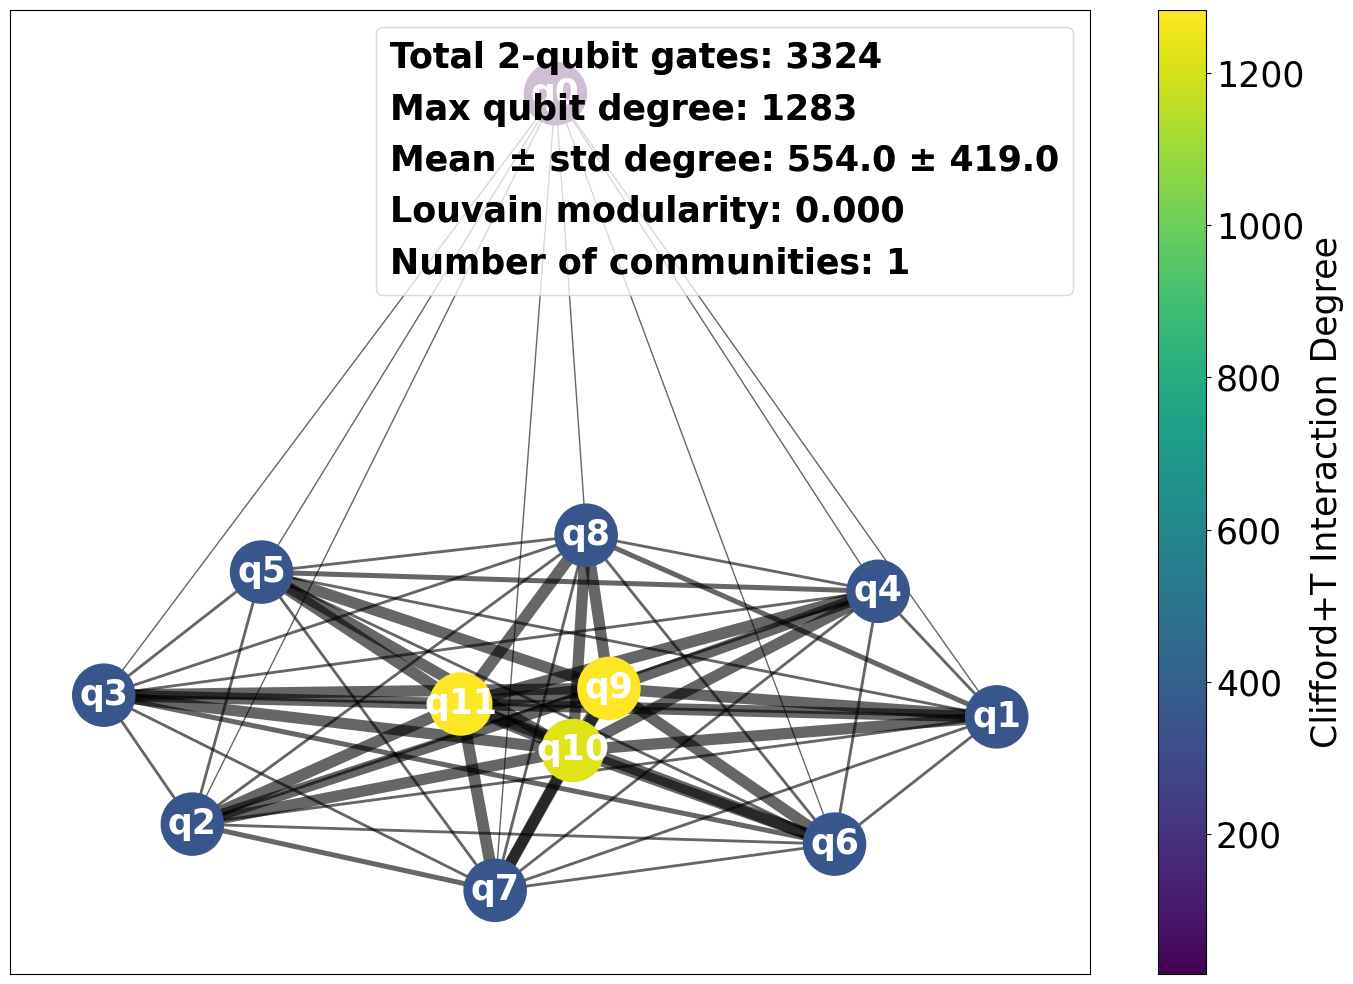

✅ Clifford+T Interaction graph created!
   - Total 2-qubit gates: 3324
   - Qubit interaction degrees: {11: 1282, 10: 1219, 9: 1283, 1: 356, 2: 356, 3: 356, 4: 356, 5: 356, 6: 356, 7: 356, 8: 356, 0: 16}


In [20]:
print("📊 Creating interaction graph visualization...")

# Use the new native function
show_clifford_t_interaction_graph(
    clifford_t_circuit,
    name=f"{title}_clifford_t_interaction_graph",
    node_size=2000,
)

📄 Plot saved as: figs/hhl_12q_t_density.pdf


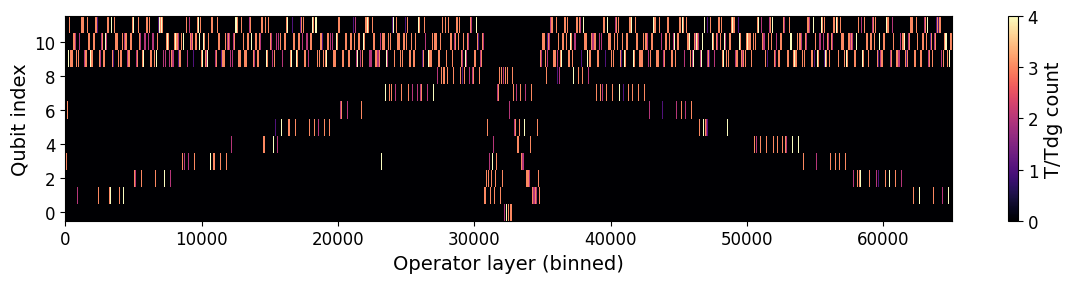

✅ Saved T-gate heatmap for 'hhl_12q_t_density'. Bins: 65072, Layers: 473283


In [21]:
plot_clifford_t_tgate_heatmap(clifford_t_circuit,
                              use_layers=False,
                              name =f"{title}_t_density",
                              time_bins=clifford_t_circuit.depth()/5
                              )

In [ ]:
from numpy import False_


print("🔄 Converting to PBC...")

start_time = time.time()

# Use the existing convert_to_pbc_circuit function directly
pbc_circuit, pbc_stats = convert_to_pbc_circuit(clifford_t_circuit, optimize_pbc=False)

conversion_time = time.time() - start_time

print(f"✅ PBC conversion completed in {conversion_time:.3f} seconds")
print(f"   - PBC circuit layers: {pbc_circuit.depth()}")
print(f"   - Total PBC gates: {len(pbc_circuit.data)}") #including barriers

🔄 Converting to PBC...
✅ PBC conversion completed in 4.719 seconds!
   - PBC circuit layers: 179172
   - Total PBC gates: 180214


In [23]:
# Analyze PBC circuit
pbc_analysis = analyze_pbc_circuit(pbc_circuit, pbc_stats)

print(f"   - T operators: {pbc_analysis.get('pbc_t_operators', 0)}")
print(
    f"   - Measurement operators: {pbc_analysis.get('pbc_measurement_operators', 0)}"
)

# Display Pauli weight statistics
if "pbc_avg_pauli_weight" in pbc_analysis:
    avg_weight = pbc_analysis["pbc_avg_pauli_weight"]
    std_weight = pbc_analysis["pbc_std_pauli_weight"]
    if isinstance(avg_weight, (int, float)):
        print(f"   - Average Pauli weight: {avg_weight:.2f} ± {std_weight:.2f}")

print("\n📋 PBC Circuit Summary:")
print(f"Number of layers: {pbc_circuit.depth()}")
print(f"Total gates: {len(pbc_circuit.data)}")

# print("\nPBC gates:")
# gate_count = 0
# for i, instruction in enumerate(pbc_circuit.data):
#     gate_name = instruction.operation.name
#     # Skip barriers
#     if gate_name == "barrier":
#         continue
#     gate_count += 1
#     qubits = [pbc_circuit.find_bit(q).index for q in instruction.qubits]
#     print(f"  {gate_count:2d}. {gate_name} on qubits {qubits}")

   - T operators: 180202
   - Measurement operators: 12
   - Average Pauli weight: 7.15 ± 2.60

📋 PBC Circuit Summary:
Number of layers: 179172
Total gates: 180214


📊 Creating interaction graph visualization...
📄 Plot saved as: figs/ hhl_12q PBC Interaction Graph.pdf


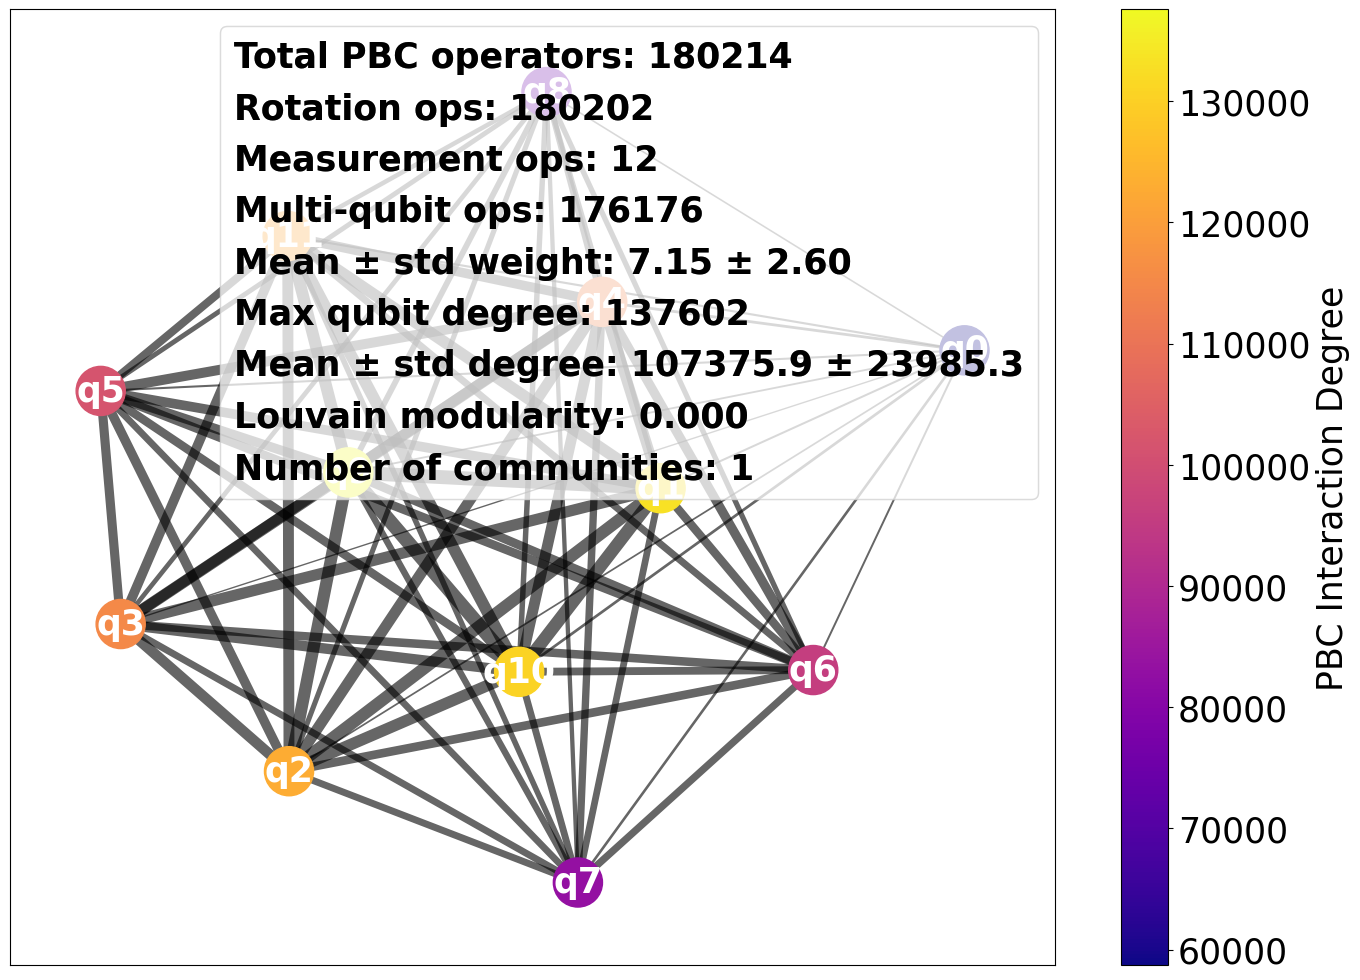

✅ PBC Interaction graph created!
   - Total PBC operators: 180214 (rot: 180202, meas: 12)
   - Multi-qubit ops: 176176
   - Mean weight: 7.15 ± 2.60


In [24]:
print("📊 Creating interaction graph visualization...")

show_pbc_interaction_graph(
    pbc_circuit,
    name =f" {title} PBC Interaction Graph"
)

📄 Plot saved as: figs/hhl_12q PBC Operator Heatmap.pdf


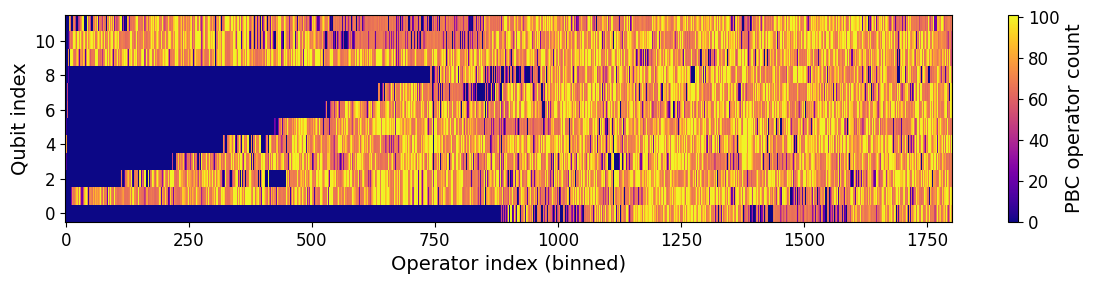

✅ Saved PBC operator heatmap for 'hhl_12q PBC Operator Heatmap'. Bins: 1802, Operators: 180214


In [31]:
plot_pbc_operator_heatmap(
    pbc_circuit,
    name =f"{title} PBC Operator Heatmap"
)

📄 Plot saved as: figs/hhl_12q PBC Weight vs Index.pdf


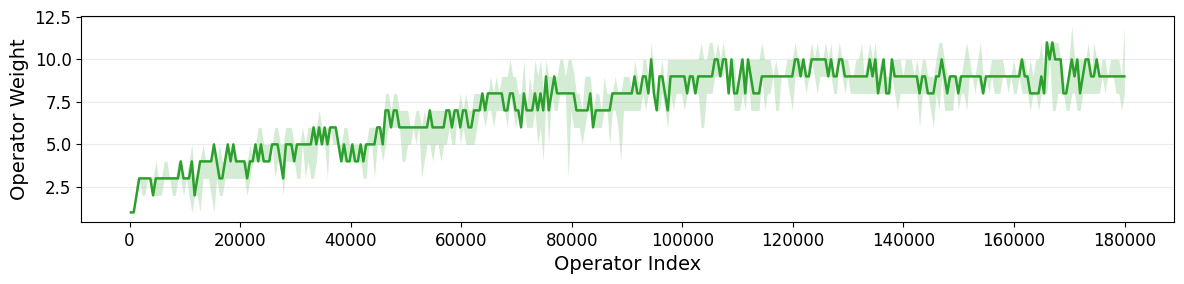

✅ Saved Pauli weight binned-bands plot for 'hhl_12q PBC Weight vs Index'. Operators binned: 360


In [25]:
plot_pbc_pauli_weight_binned_bands(pbc_circuit, bins=len(pbc_circuit.data)/500, name =f"{title} PBC Weight vs Index")

📊 Creating operator weight histogram visualization...
📄 Plot saved as: figs/hhl_12q PBC Operator Weight Distribution.pdf


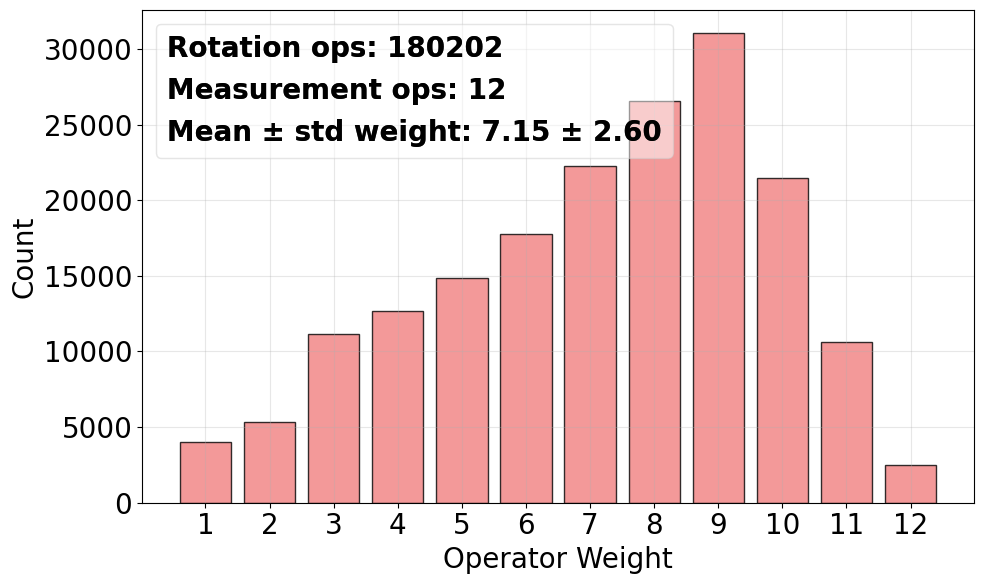

✅ PBC operator weight bar plot created!
   - Total PBC operators: 180214
   - Rotation operators: 180202
   - Measurement operators: 12
   - Weight range: 1 to 12
   - Mean weight: 7.15 ± 2.60


In [26]:
print("📊 Creating operator weight histogram visualization...")

# Use the new operator weight histogram function
show_operator_weight_histogram(
    pbc_circuit,
    name=f"{title} PBC Operator Weight Distribution"
)

📊 Creating qubit PBC operations plot visualization...
📄 Plot saved as: figs/hhl_12q PBC Operations per Qubit.pdf


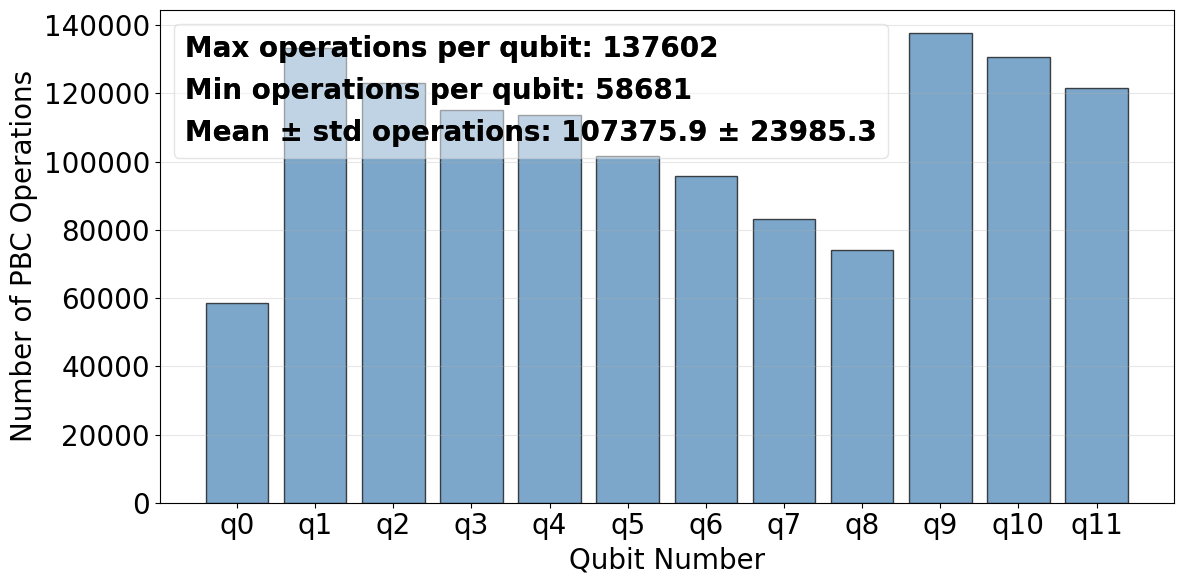

✅ PBC operations per qubit plot created!
   - Total PBC operations: 180214
   - Total rotations: 180202
   - Total measurements: 12
   - Active qubits: 12/12
   - Operations range: 58681 to 137602
   - Mean operations per qubit: 107375.9 ± 23985.3


In [27]:
print("📊 Creating qubit PBC operations plot visualization...")

# Use the new qubit PBC operations plot function
show_qubit_pbc_operations_plot(
    pbc_circuit,
    name=f"{title} PBC Operations per Qubit"
)

In [28]:
print("\n" + "=" * 80)
print(" FTCircuitBench Pipeline Summary")
print("=" * 80)

print(" Circuit Processing:")
print(
    f"   - Original circuit: {len(original_circuit.data)} gates, {original_circuit.num_qubits} qubits"
)
print(
    f"   - Clifford+T circuit: {len(clifford_t_circuit.data)} gates, {clifford_t_circuit.num_qubits} qubits"
)
print(
    f"   - PBC circuit: {len(pbc_circuit.data)} gates, {pbc_circuit.num_qubits} qubits"
)

print("\n Key Metrics:")
print(
    f"   - Gate expansion factor: {len(clifford_t_circuit.data) / len(original_circuit.data):.2f}x"
)
print(f"   - T-count: {clifford_t_stats.get('total_t_family_count', 0)}")
print(f"   - Circuit depth: {clifford_t_circuit.depth()}")

print("\n PBC Analysis:")
print(f"   - T operators: {pbc_analysis.get('pbc_t_operators', 0)}")
print(
    f"   - Measurement operators: {pbc_analysis.get('pbc_measurement_operators', 0)}"
)

if "pbc_avg_pauli_weight" in pbc_analysis:
    avg_weight = pbc_analysis["pbc_avg_pauli_weight"]
    print(f"   - Average Pauli weight: {avg_weight:.2f}")

print("\n FTCircuitBench pipeline completed successfully!")


 FTCircuitBench Pipeline Summary
 Circuit Processing:
   - Original circuit: 18212 gates, 12 qubits
   - Clifford+T circuit: 473283 gates, 12 qubits
   - PBC circuit: 180214 gates, 12 qubits

 Key Metrics:
   - Gate expansion factor: 25.99x
   - T-count: 180202
   - Circuit depth: 325361

 PBC Analysis:
   - T operators: 180202
   - Measurement operators: 12
   - Average Pauli weight: 7.15

 FTCircuitBench pipeline completed successfully!
